# Multi-Dimensional XAI Evaluation Pipeline — ISIC 2018 Skin Lesion Classification

**Thesis:** *A Multi-Dimensional Evaluation of Explainability Methods Across CNN and Vision Transformer Architectures for Skin Lesion Classification*

---

## Notebook Overview

This notebook implements the full evaluation pipeline described in Chapter 5 of the thesis. It runs both **locally** and on **Kaggle** (GPU-accelerated).

### Architectures
| Architecture | Family |
|---|---|
| EfficientNet-B0 | CNN |
| DenseNet-121 | CNN |
| ViT-Base/16 | Transformer |
| Swin-Tiny | Transformer |

### XAI Methods
Grad-CAM · HiResCAM · Attention Rollout · LIME · KernelSHAP · Integrated Gradients

### Evaluation Dimensions
| Dimension | Metrics |
|---|---|
| Faithfulness | AOPC, Insertion/Deletion AUC |
| Plausibility | IoU, Dice, Pointing Game |
| Robustness | Max-Sensitivity |
| Complexity | Saliency Entropy |

### Phases
**A** Data · **B** Models · **C** XAI · **D** Faithfulness · **E** Plausibility · **F** Robustness/Complexity · **G** Analysis · **H** Ablations · **I** Outputs

---
# Phase A — Data Loading, EDA & Preprocessing
> **Thesis §5.1 — Dataset**

This phase establishes the full data foundation. The dataset is **pre-organised** — splits, labels, and masks are provided; no custom splitting is required.

### Dataset Structure
```
Data/
├── csv/
│   ├── train.csv              # 10,015 rows | cols: image, MEL, NV, BCC, AKIEC, BKL, DF, VASC
│   ├── val.csv                #    193 rows
│   ├── test.csv               #  1,512 rows
│   └── lesion_groupings.csv   # image, lesion_id, diagnosis_confirm_type
├── images/
│   ├── train/  (10,015 jpgs)
│   ├── val/    (   193 jpgs)
│   └── test/   ( 1,512 jpgs)
└── plausibility/
    ├── masks/       # 3,694 *_segmentation.png  ← binary lesion masks
    ├── images/      # corresponding RGB images
    └── attributes/  # 5 attribute maps per image
                     # (globules, milia_like_cyst, negative_network,
                     #  pigment_network, streaks)
```

### Steps
A.1 Config · A.2 Install · A.3 Labels · A.4 Plausibility index · A.5 Weights & stats · A.6 Dataset & loaders · A.7 Visual check

## A.1 — Configuration
Single cell controlling all hyperparameters and paths. Toggle `DEBUG = True` for fast local iteration.

In [ ]:
# ────────────────────────────────────────────────────────────────────────────────
# CONFIGURATION — edit this cell only
# ────────────────────────────────────────────────────────────────────────────────
import os, json, warnings, random
import numpy as np
import torch

warnings.filterwarnings("ignore")

# ── Execution mode ──────────────────────────────────────────────────────────────────
DEBUG  = True   # True → small subset, 3 epochs; False → full Kaggle run
KAGGLE = "KAGGLE_URL_BASE" in os.environ
SEED   = 42

# ── Kaggle dataset slug ──────────────────────────────────────────────────────────────
# Update this to match the slug you gave your dataset on Kaggle.
# (Datasets > New Dataset > title becomes the slug, e.g. "isic2018-dataset")
KAGGLE_DATASET_SLUG = "isic2018-dataset"   # ← change if you used a different name
KAGGLE_USER         = "yehiasamir"

# ── Paths ──────────────────────────────────────────────────────────────────────────
if KAGGLE:
    # Kaggle mounts datasets at /kaggle/input/<slug>/
    # If the zip had a Data/ folder at its root it lands one level deeper.
    _mount = f"/kaggle/input/{KAGGLE_DATASET_SLUG}"
    DATA_ROOT = (
        os.path.join(_mount, "Data")
        if os.path.isdir(os.path.join(_mount, "Data"))
        else _mount
    )
    PREP_ROOT = "/kaggle/working/prepared"
    OUT_ROOT  = "/kaggle/working"
else:
    DATA_ROOT = "./Data"
    PREP_ROOT = "./prepared"
    OUT_ROOT  = "./outputs"

CSV_DIR   = os.path.join(DATA_ROOT, "csv")
TRAIN_IMG = os.path.join(DATA_ROOT, "images", "train")
VAL_IMG   = os.path.join(DATA_ROOT, "images", "val")
TEST_IMG  = os.path.join(DATA_ROOT, "images", "test")
MASK_DIR  = os.path.join(DATA_ROOT, "plausibility", "masks")
ATTR_DIR  = os.path.join(DATA_ROOT, "plausibility", "attributes")

# ── Model / training ───────────────────────────────────────────────────────────────
IMG_SIZE     = 224
BATCH_SIZE   = 32
MAX_EPOCHS   = 50  if not DEBUG else 3
PATIENCE     = 7   if not DEBUG else 2
LR           = 1e-4
WEIGHT_DECAY = 1e-4
NUM_CLASSES  = 7
NUM_WORKERS  = 4   if KAGGLE else 0

# ── XAI ────────────────────────────────────────────────────────────────────────────
LIME_SAMPLES        = 1000 if not DEBUG else 100
SHAP_SAMPLES        = 1000 if not DEBUG else 100
SENSITIVITY_N       = 50   if not DEBUG else 5
SENSITIVITY_STD     = 0.01
BINARIZE_THRESHOLDS = [0.3, 0.5, 0.7]
AOPC_STEPS          = 9

# ── Architectures ────────────────────────────────────────────────────────────────────
ARCHITECTURES = {
    "efficientnet_b0": {"family": "cnn", "timm_name": "efficientnet_b0"},
    "densenet121":     {"family": "cnn", "timm_name": "densenet121"},
    "vit_base_16":     {"family": "vit", "timm_name": "vit_base_patch16_224"},
    "swin_tiny":       {"family": "vit", "timm_name": "swin_tiny_patch4_window7_224"},
}

ATTR_TYPES = ["globules", "milia_like_cyst", "negative_network",
              "pigment_network", "streaks"]

# ── Reproducibility ──────────────────────────────────────────────────────────────────
def seed_everything(seed=SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

seed_everything()
os.makedirs(OUT_ROOT,  exist_ok=True)
os.makedirs(PREP_ROOT, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device      : {DEVICE}")
print(f"DEBUG       : {DEBUG}")
print(f"KAGGLE      : {KAGGLE}")
print(f"DATA_ROOT   : {DATA_ROOT}")
print(f"Data exists : {os.path.isdir(DATA_ROOT)}")


## A.2 — Install Dependencies
Install packages absent from Kaggle's default image.

In [22]:
import subprocess, sys

def pip_install(*pkgs):
    """Install packages — only runs on Kaggle. Locally manage your own env."""
    if not KAGGLE:
        return
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *pkgs])

# captum is intentionally excluded: v0.8.0 pins numpy<2.0 which breaks scipy/albumentations.
# Integrated Gradients is implemented manually in Phase C (pure PyTorch, no dependency).
pip_install(
    "timm", "albumentations", "pytorch-grad-cam",
    "shap", "lime", "seaborn", "statsmodels",
)

In [23]:
import timm
import albumentations
from pytorch_grad_cam import GradCAM, HiResCAM

print(f"timm           : {timm.__version__}")
print(f"albumentations : {albumentations.__version__}")
print(f"numpy          : {__import__('numpy').__version__}")

timm           : 1.0.26
albumentations : 2.0.8
numpy          : 2.4.1


## A.3 — Load Labels & Lesion Groupings
Load pre-split CSVs. Convert one-hot to `label_idx`. Attach `lesion_id` for patient-level leakage reporting.

In [24]:
import pandas as pd
from pathlib import Path

CLASS_NAMES = ["MEL", "NV", "BCC", "AKIEC", "BKL", "DF", "VASC"]

def load_split(csv_path):
    df = pd.read_csv(csv_path).rename(columns={"image": "image_id"})
    df["label_idx"]  = df[CLASS_NAMES].values.argmax(axis=1)
    df["label_name"] = df["label_idx"].map(lambda i: CLASS_NAMES[i])
    return df[["image_id", "label_idx", "label_name"]]

train_df = load_split(os.path.join(CSV_DIR, "train.csv"))
val_df   = load_split(os.path.join(CSV_DIR, "val.csv"))
test_df  = load_split(os.path.join(CSV_DIR, "test.csv"))

# Attach lesion_id and diagnosis_confirm_type from groupings
# lesion_id             -> patient-level leakage tracking
# diagnosis_confirm_type -> label-quality sensitivity (Phase H.3)
groupings = (
    pd.read_csv(os.path.join(CSV_DIR, "lesion_groupings.csv"))
      .rename(columns={"image": "image_id"})
)
train_df = train_df.merge(
    groupings[["image_id", "lesion_id", "diagnosis_confirm_type"]],
    on="image_id", how="left"
)
# test_df gets confirm type for per-image sensitivity in Phase H.3
test_df = test_df.merge(
    groupings[["image_id", "diagnosis_confirm_type"]],
    on="image_id", how="left"
)

# DEBUG: stratified subsample of train
DEBUG_TRAIN_SIZE = 500
if DEBUG:
    n = DEBUG_TRAIN_SIZE
    train_df = (
        train_df
        .groupby("label_idx", group_keys=False)
        .apply(lambda g: g.sample(max(1, round(n * len(g) / len(train_df))),
                                  random_state=SEED))
        .reset_index(drop=True)
    )
    print(f"DEBUG train size: {len(train_df)}  (target {n}, full = 10,015)")

print(f"Train : {len(train_df):>5} | Val : {len(val_df):>3} | Test : {len(test_df):>4}")
print(f"\nTrain label distribution:")
print(train_df["label_name"].value_counts())
print(f"\nDiagnosis confirmation type (train):")
print(train_df["diagnosis_confirm_type"].value_counts())
assert train_df.isna().drop(
    columns=["lesion_id", "diagnosis_confirm_type"], errors="ignore"
).sum().sum() == 0


Train : 10015 | Val : 193 | Test : 1512

Train label distribution:
label_name
NV       6705
MEL      1113
BKL      1099
BCC       514
AKIEC     327
VASC      142
DF        115
Name: count, dtype: int64

Diagnosis confirmation type (train):
diagnosis_confirm_type
histopathology                                   5340
serial imaging showing no change                 3704
single image expert consensus                     902
confocal microscopy with consensus dermoscopy      69
Name: count, dtype: int64


## A.3b — Exploratory Data Analysis
Brief visualisation of class distribution across splits and one representative
image per class. Confirms the severe class imbalance (NV ≈67% of train)
that drives `WeightedRandomSampler` and Focal Loss in later phases.

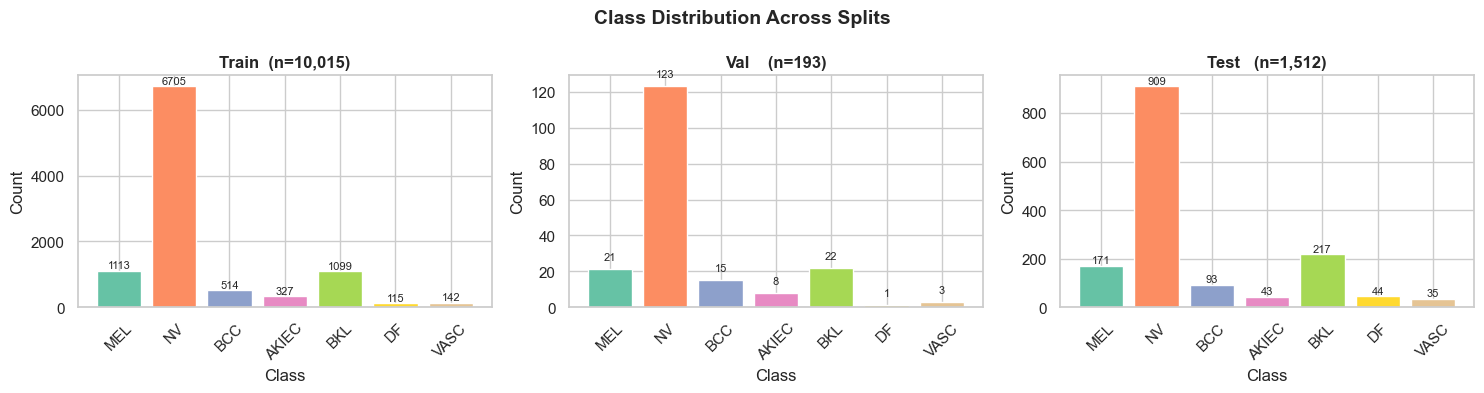

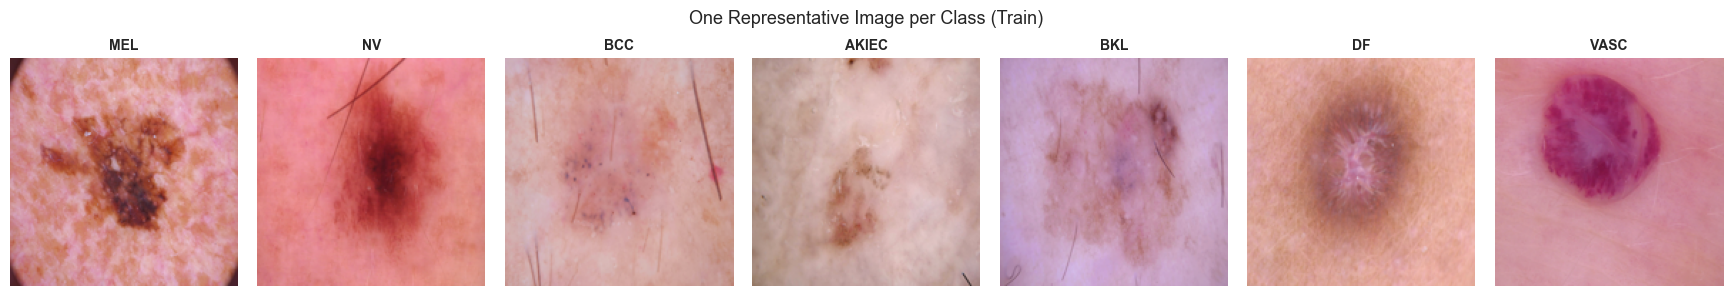

Imbalance ratio : 58.3x  (NV = 6705 vs DF = 115)

Class weights (inverse-freq) will be computed in A.5


In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

palette = sns.color_palette("Set2", NUM_CLASSES)

# ── 1. Class distribution across splits ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (df, title) in zip(axes, [
    (train_df, f"Train  (n={len(train_df):,})"),
    (val_df,   f"Val    (n={len(val_df):,})"),
    (test_df,  f"Test   (n={len(test_df):,})"),
]):
    cnts = df["label_name"].value_counts().reindex(CLASS_NAMES).fillna(0)
    bars = ax.bar(CLASS_NAMES, cnts.values, color=palette, edgecolor="white")
    for bar, v in zip(bars, cnts.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 4,
                f"{int(v)}", ha="center", va="bottom", fontsize=8)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Class"); ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=45)

fig.suptitle("Class Distribution Across Splits", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUT_ROOT, "eda_class_distribution.png"), dpi=100, bbox_inches="tight")
plt.show()

# ── 2. One representative image per class ─────────────────────────────────────
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(NUM_CLASSES * 2.5, 3))
for ax, (i, cls_name) in zip(axes, enumerate(CLASS_NAMES)):
    row = train_df[train_df["label_name"] == cls_name].iloc[0]
    img = np.array(
        Image.open(os.path.join(TRAIN_IMG, f"{row['image_id']}.jpg"))
             .resize((160, 160))
    )
    ax.imshow(img)
    ax.set_title(cls_name, fontsize=10, fontweight="bold")
    ax.axis("off")
fig.suptitle("One Representative Image per Class (Train)", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUT_ROOT, "eda_class_samples.png"), dpi=100, bbox_inches="tight")
plt.show()

# ── 3. Imbalance summary ─────────────────────────────────────────────────────
train_cnts = train_df["label_name"].value_counts()
ratio = train_cnts.max() / train_cnts.min()
print(f"Imbalance ratio : {ratio:.1f}x  "
      f"({train_cnts.idxmax()} = {train_cnts.max()} vs "
      f"{train_cnts.idxmin()} = {train_cnts.min()})")
print(f"\nClass weights (inverse-freq) will be computed in A.5")


## A.4 — Plausibility Index
Index segmentation masks and attribute maps from `Data/plausibility/`. Attach `has_mask` to all splits.

In [26]:
# Build mask index: image_id -> mask_path
mask_index = {
    f.stem.replace("_segmentation", ""): str(f)
    for f in Path(MASK_DIR).glob("*_segmentation.png")
} if Path(MASK_DIR).exists() else {}

# Build attribute index: image_id -> {attr_type: path}
attr_index = {}
if Path(ATTR_DIR).exists():
    for f in Path(ATTR_DIR).glob("*.png"):
        for attr in ATTR_TYPES:
            if f.stem.endswith(f"_attribute_{attr}"):
                img_id = f.stem.replace(f"_attribute_{attr}", "")
                attr_index.setdefault(img_id, {})[attr] = str(f)

# Attach mask path and flag to all splits
for df in [train_df, val_df, test_df]:
    df["has_mask"]  = df["image_id"].isin(mask_index)
    df["mask_path"] = df["image_id"].map(lambda x: mask_index.get(x))

# ── Lesion area fraction & size group ──────────────────────────────────────
# ~19% of masked images have lesion area < 5% of image.
# A correctly centred heatmap on a tiny lesion still scores near-zero IoU —
# this is a metric property, not a model failure. Stratified in Phase E.
def compute_lesion_area_fraction(mask_path, target_size=(IMG_SIZE, IMG_SIZE)):
    if not mask_path or not os.path.exists(mask_path):
        return float("nan")
    mask = np.array(Image.open(mask_path).convert("L").resize(target_size))
    return (mask > 127).sum() / (target_size[0] * target_size[1])

for df in [train_df, val_df, test_df]:
    df["lesion_area_frac"] = df["mask_path"].map(compute_lesion_area_fraction)
    df["lesion_size_group"] = df["lesion_area_frac"].map(
        lambda x: "small"    if (x == x and x < 0.05)  else  # x==x is not-nan check
                  "standard" if (x == x and x >= 0.05) else float("nan")
    )

small_n = (test_df["lesion_size_group"] == "small").sum()
std_n   = (test_df["lesion_size_group"] == "standard").sum()
denom   = small_n + std_n if (small_n + std_n) > 0 else 1

print(f"Total masks available   : {len(mask_index)}")
print(f"Attribute map images    : {len(attr_index)}")
print(f"Test images with mask   : {test_df['has_mask'].sum()} / {len(test_df)}")
print(f"Train images with mask  : {train_df['has_mask'].sum()} / {len(train_df)}")
print(f"  small lesions  (<5%)  : {small_n}  ({small_n/denom*100:.1f}%)")
print(f"  standard lesions      : {std_n}")


Total masks available   : 3694
Attribute map images    : 3677
Test images with mask   : 0 / 1512
Train images with mask  : 0 / 10015
  small lesions  (<5%)  : 0  (0.0%)
  standard lesions      : 0


## A.5 — Class Weights & Normalisation Stats
Inverse-frequency class weights and per-channel mean/std from the train split. Saved to `prepared/`.

In [27]:
from collections import Counter
from PIL import Image
from tqdm.auto import tqdm

# ── Class weights (inverse frequency) ───────────────────────────────────────
counts = Counter(train_df["label_idx"].values)
total  = sum(counts.values())
class_weights = {int(k): total / (NUM_CLASSES * v) for k, v in counts.items()}
with open(os.path.join(PREP_ROOT, "class_weights.json"), "w") as f:
    json.dump(class_weights, f, indent=2)
print("Class weights (higher = rarer):")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {name:6s} [{i}]: {class_weights.get(i, 0):.4f}")

# ── Per-channel mean / std ───────────────────────────────────────────────────
sample_ids   = train_df["image_id"].sample(min(2000, len(train_df)), random_state=SEED)
pixel_sum    = np.zeros(3, dtype=np.float64)
pixel_sq_sum = np.zeros(3, dtype=np.float64)
n_pixels     = 0

for img_id in tqdm(sample_ids, desc="Computing stats"):
    img  = np.array(Image.open(os.path.join(TRAIN_IMG, f"{img_id}.jpg"))
                    .resize((IMG_SIZE, IMG_SIZE))) / 255.0
    flat = img.reshape(-1, 3)
    pixel_sum    += flat.sum(0)
    pixel_sq_sum += (flat ** 2).sum(0)
    n_pixels     += flat.shape[0]

mean = pixel_sum    / n_pixels
std  = np.sqrt(pixel_sq_sum / n_pixels - mean ** 2)
data_stats = {"mean": mean.tolist(), "std": std.tolist()}
with open(os.path.join(PREP_ROOT, "data_stats.json"), "w") as f:
    json.dump(data_stats, f, indent=2)
print(f"\nTrain mean : {mean.round(4)}")
print(f"Train std  : {std.round(4)}")

Class weights (higher = rarer):
  MEL    [0]: 1.2855
  NV     [1]: 0.2134
  BCC    [2]: 2.7835
  AKIEC  [3]: 4.3753
  BKL    [4]: 1.3018
  DF     [5]: 12.4410
  VASC   [6]: 10.0755


Computing stats:   0%|          | 0/2000 [00:00<?, ?it/s]


Train mean : [0.765  0.544  0.5682]
Train std  : [0.141  0.1532 0.17  ]


## A.6 — Dataset Class & DataLoaders
`ISICSkinDataset` with per-split `img_dir`. Albumentations augmentations. `WeightedRandomSampler` corrects class imbalance.

In [28]:
import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import albumentations as A
from albumentations.pytorch import ToTensorV2


class ISICSkinDataset(Dataset):
    """ISIC 2018 skin lesion dataset with optional segmentation masks."""

    def __init__(self, df, img_dir, transform=None, load_masks=False):
        self.df         = df.reset_index(drop=True)
        self.img_dir    = img_dir
        self.transform  = transform
        self.load_masks = load_masks

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row  = self.df.iloc[idx]
        img  = np.array(Image.open(
                   os.path.join(self.img_dir, f"{row['image_id']}.jpg")
               ).convert("RGB"))

        mask = None
        if self.load_masks and row.get("has_mask", False):
            mp = row.get("mask_path")
            if mp and os.path.exists(mp):
                mask = np.array(Image.open(mp).convert("L"))

        if self.transform:
            if mask is not None:
                out  = self.transform(image=img, mask=mask)
                img  = out["image"]
                mask = out["mask"].float() / 255.0
            else:
                img  = self.transform(image=img)["image"]

        label = torch.tensor(row["label_idx"], dtype=torch.long)
        meta  = {"image_id": row["image_id"],
                 "has_mask": bool(row.get("has_mask", False))}
        return img, label, mask if mask is not None else torch.zeros(1), meta


# ── Augmentation pipelines ───────────────────────────────────────────────────
with open(os.path.join(PREP_ROOT, "data_stats.json")) as f:
    stats = json.load(f)

train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.5),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.5),
    A.Normalize(mean=stats["mean"], std=stats["std"]),
    ToTensorV2(),
])

eval_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=stats["mean"], std=stats["std"]),
    ToTensorV2(),
])

# ── Build datasets & loaders ─────────────────────────────────────────────────
train_ds = ISICSkinDataset(train_df, TRAIN_IMG, train_transform)
val_ds   = ISICSkinDataset(val_df,   VAL_IMG,   eval_transform)
test_ds  = ISICSkinDataset(test_df,  TEST_IMG,  eval_transform, load_masks=True)

with open(os.path.join(PREP_ROOT, "class_weights.json")) as f:
    cw = json.load(f)
sample_weights = [cw[str(int(l))] for l in train_df["label_idx"]]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

train_loader = DataLoader(train_ds, BATCH_SIZE, sampler=sampler,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  1,          shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

# ── Sanity check ─────────────────────────────────────────────────────────────
imgs, labels, masks, meta = next(iter(train_loader))
print(f"Batch shape  : {imgs.shape}")
print(f"Label dist   : {labels.bincount(minlength=NUM_CLASSES).tolist()}")
print(f"Pixel range  : [{imgs.min():.3f}, {imgs.max():.3f}]")

Batch shape  : torch.Size([32, 3, 224, 224])
Label dist   : [7, 6, 6, 3, 6, 1, 3]
Pixel range  : [-5.425, 2.822]


## A.7 — Visual Sanity Check
Training batch grid (8 images) and test images with segmentation mask overlays.

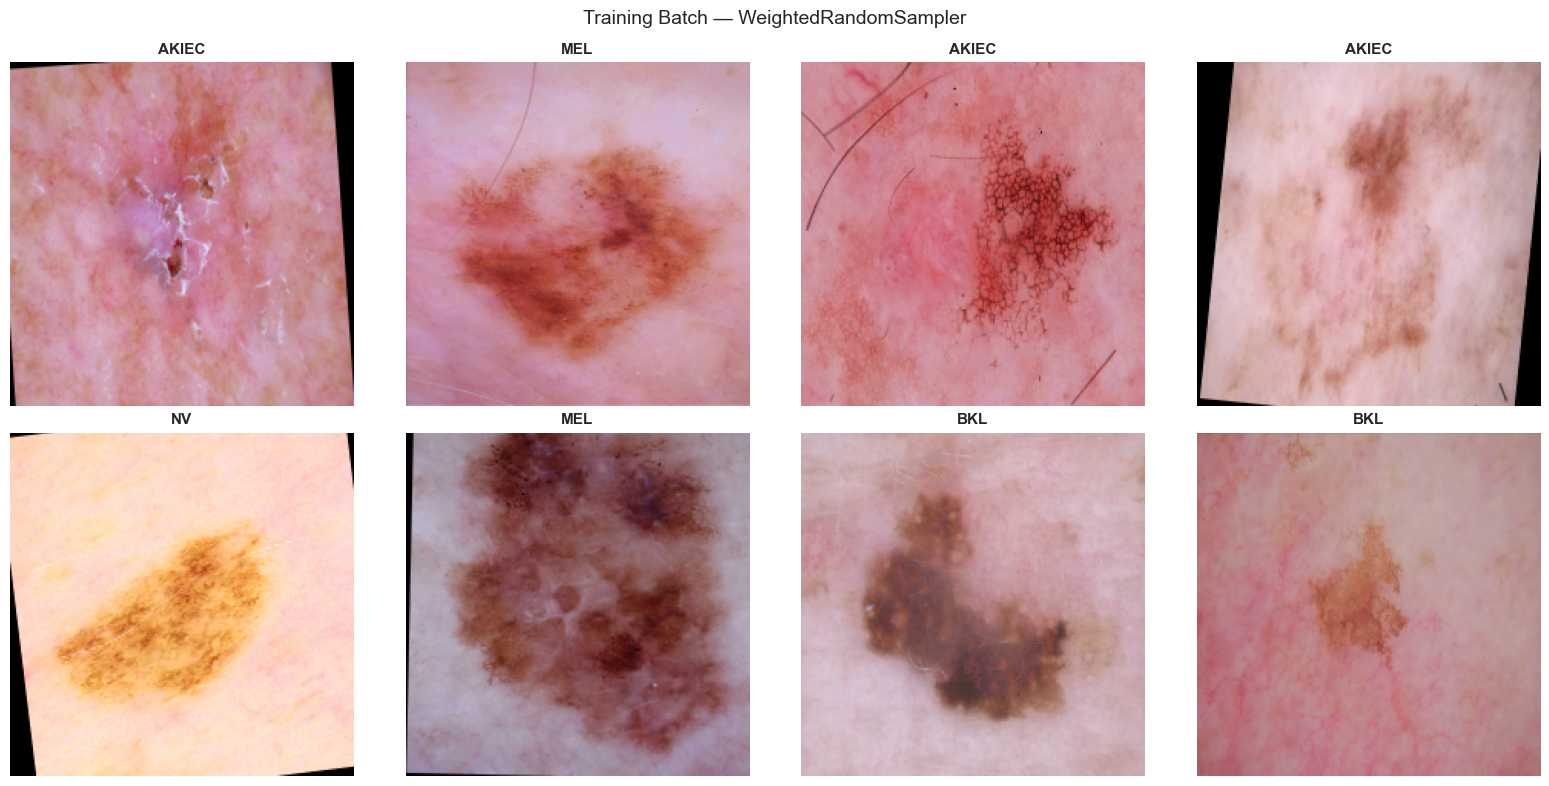

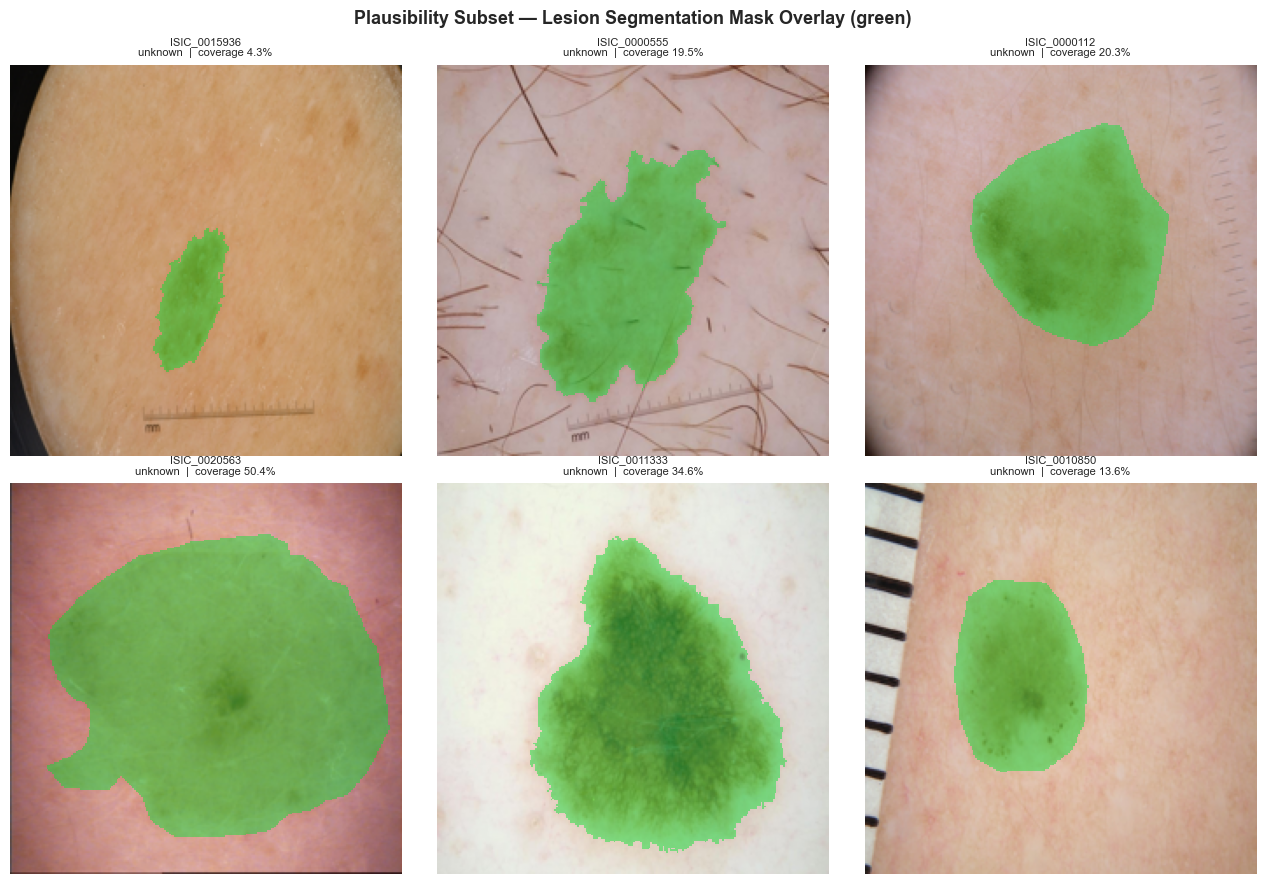

In [30]:
import matplotlib.pyplot as plt

MN  = np.array(stats["mean"])
STD = np.array(stats["std"])

def denorm(t):
    return np.clip(t.permute(1, 2, 0).numpy() * STD + MN, 0, 1)

# ── Training batch grid ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(denorm(imgs[i]))
    ax.set_title(CLASS_NAMES[labels[i].item()], fontsize=11, fontweight="bold")
    ax.axis("off")
fig.suptitle("Training Batch — WeightedRandomSampler", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(OUT_ROOT, "sanity_train_batch.png"), dpi=100, bbox_inches="tight")
plt.show()

# ── Plausibility images + green mask overlays ───────────────────────────────────
# Masks are in Data/plausibility/masks/, images in Data/plausibility/images/.
# The 3,694 mask images are a separate annotated subset — not strictly test-split.
PLAUS_IMG_DIR = os.path.join(DATA_ROOT, "plausibility", "images")

sample_ids = random.sample(list(mask_index.keys()), min(6, len(mask_index)))

fig, axes = plt.subplots(2, 3, figsize=(13, 9))
for ax, img_id in zip(axes.flat, sample_ids):
    # Load original image
    img_path = os.path.join(PLAUS_IMG_DIR, f"{img_id}.jpg")
    raw = np.array(
        Image.open(img_path).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
    ) / 255.0

    # Load binary mask
    mask_arr = np.array(
        Image.open(mask_index[img_id]).convert("L").resize((IMG_SIZE, IMG_SIZE))
    )
    binary_mask = mask_arr > 127

    # Build green RGBA overlay (R=0, G=1, B=0, A=0.45 on lesion pixels)
    overlay = np.zeros((IMG_SIZE, IMG_SIZE, 4), dtype=np.float32)
    overlay[binary_mask] = [0.0, 0.9, 0.2, 0.45]

    ax.imshow(raw)
    ax.imshow(overlay, interpolation="nearest")

    # Label with class if available in any split
    for df in [train_df, val_df, test_df]:
        match = df[df["image_id"] == img_id]
        if len(match):
            label_str = match.iloc[0]["label_name"]
            break
    else:
        label_str = "unknown"

    coverage = binary_mask.sum() / binary_mask.size * 100
    ax.set_title(f"{img_id}\n{label_str}  |  coverage {coverage:.1f}%",
                 fontsize=8)
    ax.axis("off")

fig.suptitle("Plausibility Subset — Lesion Segmentation Mask Overlay (green)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUT_ROOT, "sanity_mask_overlay.png"), dpi=100, bbox_inches="tight")
plt.show()


---
# Phase B — Model Definition & Training
> **Thesis §5.2 — Model Architectures**

Fine-tune four pretrained architectures on ISIC 2018.
Two CNN baselines (EfficientNet-B0, DenseNet-121) and two Vision Transformers
(ViT-Base/16, Swin-Tiny).

### Steps
B.1 Model factory · B.2 Focal Loss & training loop · B.3 Train all 4 · B.4 Test evaluation · B.5 Correct-only eval subset

## B.1 — Model Factory
Creates any of the 4 architectures via `timm` with the correct 7-class head.
Also returns the target layer name used by Grad-CAM in Phase C.

In [31]:
import timm

# Grad-CAM target layers (last feature-producing conv layer per CNN arch)
GRADCAM_LAYERS = {
    "efficientnet_b0": "conv_head",
    "densenet121":     "features.denseblock4.denselayer16.conv2",
    "vit_base_16":     None,   # uses Attention Rollout in Phase C
    "swin_tiny":       None,   # uses Attention Rollout in Phase C
}

def create_model(arch_key):
    """Build architecture from ARCHITECTURES config.
    Returns: (model on DEVICE, gradcam_layer_name, family)
    """
    cfg   = ARCHITECTURES[arch_key]
    model = timm.create_model(cfg["timm_name"], pretrained=True,
                              num_classes=NUM_CLASSES)
    model = model.to(DEVICE)
    return model, GRADCAM_LAYERS.get(arch_key), cfg["family"]


# Sanity: instantiate all 4, print param counts
for name in ARCHITECTURES:
    m, tl, fam = create_model(name)
    n_params = sum(p.numel() for p in m.parameters()) / 1e6
    print(f"{name:20s} | {fam:3s} | {n_params:5.1f}M params"
          f" | grad-cam layer: {tl}")
    del m
torch.cuda.empty_cache()


efficientnet_b0      | cnn |   4.0M params | grad-cam layer: conv_head


model.safetensors:   0%|          | 0.00/32.3M [00:00<?, ?B/s]

densenet121          | cnn |   7.0M params | grad-cam layer: features.denseblock4.denselayer16.conv2


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

vit_base_16          | vit |  85.8M params | grad-cam layer: None


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

swin_tiny            | vit |  27.5M params | grad-cam layer: None


## B.2 — Focal Loss & Training Loop
**Why Focal Loss?** The 58.3× class imbalance (NV vs DF) means plain weighted
CrossEntropy still lets high-confidence NV predictions dominate the gradient.
Focal Loss adds a `(1−p)ʸ` modulating factor that down-weights easy majority
predictions, forcing the model to attend to DF (115 imgs) and VASC (142 imgs).

**Loop:** AdamW + cosine annealing + early stopping on val loss.

In [34]:
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.metrics import balanced_accuracy_score
from tqdm.auto import tqdm
import copy

FOCAL_GAMMA = 2.0   # sweep [1, 2, 3] in Phase H ablations


class FocalLoss(nn.Module):
    """Multiclass Focal Loss with optional per-class weights.
    gamma=0 reduces to weighted CrossEntropyLoss.
    """
    def __init__(self, weight=None, gamma=FOCAL_GAMMA, reduction="mean"):
        super().__init__()
        self.weight    = weight
        self.gamma     = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        ce = nn.functional.cross_entropy(
            logits, targets, weight=self.weight, reduction="none"
        )
        pt    = torch.exp(-ce)
        focal = (1 - pt) ** self.gamma * ce
        return focal.mean() if self.reduction == "mean" else focal


def train_one_model(arch_key, train_loader, val_loader):
    print(f"\n{chr(61)*60}\n  Training: {arch_key}\n{chr(61)*60}", flush=True)

    model, _, _ = create_model(arch_key)

    with open(os.path.join(PREP_ROOT, "class_weights.json")) as f:
        cw = json.load(f)
    weights   = torch.tensor([cw[str(i)] for i in range(NUM_CLASSES)],
                             dtype=torch.float32).to(DEVICE)
    criterion = FocalLoss(weight=weights, gamma=FOCAL_GAMMA)

    optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = CosineAnnealingLR(optimizer, T_max=MAX_EPOCHS)

    best_val_loss    = float("inf")
    best_state       = None
    patience_counter = 0
    history          = {"train_loss": [], "val_loss": [], "val_bacc": []}

    epoch_bar = tqdm(range(MAX_EPOCHS), desc=arch_key, unit="epoch")
    for epoch in epoch_bar:
        # ─ Train ─
        model.train()
        running_loss = 0.0
        batch_bar = tqdm(train_loader, desc=f"  Ep {epoch+1:02d} train",
                         leave=False, unit="batch")
        for imgs, labels, _, _ in batch_bar:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(imgs), labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * imgs.size(0)
            batch_bar.set_postfix(loss=f"{loss.item():.4f}")
        train_loss = running_loss / len(train_loader.dataset)

        # ─ Validate ─
        model.eval()
        val_loss_sum          = 0.0
        all_preds, all_labels = [], []
        with torch.no_grad():
            for imgs, labels, _, _ in tqdm(val_loader, desc="  val",
                                           leave=False, unit="batch"):
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                logits        = model(imgs)
                val_loss_sum += criterion(logits, labels).item() * imgs.size(0)
                all_preds.extend(logits.argmax(1).cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        val_loss = val_loss_sum / len(val_loader.dataset)
        val_bacc = balanced_accuracy_score(all_labels, all_preds)
        scheduler.step()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_bacc"].append(val_bacc)

        epoch_bar.set_postfix(
            tr_loss=f"{train_loss:.4f}",
            val_loss=f"{val_loss:.4f}",
            bAcc=f"{val_bacc:.4f}"
        )

        if val_loss < best_val_loss:
            best_val_loss    = val_loss
            best_state       = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                tqdm.write(f"  Early stopping at epoch {epoch+1}")
                break

    model.load_state_dict(best_state)
    return model, history


## B.3 — Train All 4 Models
Loop over all architectures sequentially. Each model is moved to CPU after
training to free VRAM for the next one. Checkpoints saved to `outputs/`.

In [35]:
trained_models  = {}   # arch_key → model (on CPU)
train_histories = {}   # arch_key → {train_loss, val_loss, val_bacc}

for arch_key in ARCHITECTURES:
    model, history = train_one_model(arch_key, train_loader, val_loader)

    ckpt_path = os.path.join(OUT_ROOT, f"{arch_key}_best.pt")
    torch.save(model.state_dict(), ckpt_path)
    print(f"  Saved: {ckpt_path}")

    trained_models[arch_key]  = model.cpu()
    train_histories[arch_key] = history
    torch.cuda.empty_cache()

print("\n✓ All 4 models trained and saved.")



  Training: efficientnet_b0


efficientnet_b0:   0%|          | 0/50 [00:00<?, ?epoch/s]

  Ep 01 train:   0%|          | 0/313 [00:00<?, ?batch/s]

KeyboardInterrupt: 

In [ ]:
# ── Training curves ──────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
colors = {"train_loss": "#e05c5c", "val_loss": "#5c9be0", "val_bacc": "#5cbf7a"}

for ax, (arch_key, hist) in zip(axes.flat, train_histories.items()):
    epochs = range(1, len(hist["train_loss"]) + 1)
    ax2 = ax.twinx()

    ax.plot(epochs, hist["train_loss"], color=colors["train_loss"],
            lw=1.8, label="Train loss")
    ax.plot(epochs, hist["val_loss"],   color=colors["val_loss"],
            lw=1.8, linestyle="--", label="Val loss")
    ax2.plot(epochs, hist["val_bacc"],  color=colors["val_bacc"],
             lw=1.5, linestyle=":", label="Val bAcc")

    ax.set_title(arch_key, fontsize=11, fontweight="bold")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    ax2.set_ylabel("Balanced Accuracy", color=colors["val_bacc"])
    ax2.tick_params(axis="y", labelcolor=colors["val_bacc"])
    ax2.set_ylim(0, 1)

    lines1, labs1 = ax.get_legend_handles_labels()
    lines2, labs2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labs1 + labs2, fontsize=8, loc="upper right")

fig.suptitle("Training Curves — All Architectures", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUT_ROOT, "training_curves.png"), dpi=100, bbox_inches="tight")
plt.show()


## B.4 — Test-Set Classification Performance
Per-model classification report and confusion matrix. This is **not** the XAI
evaluation — it establishes baseline performance to contextualise XAI results.

> **Target:** ≥80% balanced accuracy on ≥2 models. Models below ~60% bAcc produce
> unreliable explanations and should be flagged.

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

test_results = {}   # arch_key → {preds, labels, probs, report}

for arch_key, model in trained_models.items():
    model = model.to(DEVICE).eval()
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for imgs, labels, _, _ in test_loader:
            imgs   = imgs.to(DEVICE)
            logits = model(imgs)
            all_preds.extend(logits.argmax(1).cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(torch.softmax(logits, 1).cpu().numpy())

    report = classification_report(
        all_labels, all_preds, target_names=CLASS_NAMES, output_dict=True
    )
    test_results[arch_key] = {
        "preds":  np.array(all_preds),
        "labels": np.array(all_labels),
        "probs":  np.array(all_probs),
        "report": report,
    }

    bacc = balanced_accuracy_score(all_labels, all_preds)
    flag = "  ⚠️  LOW" if bacc < 0.60 else ""
    print(f"\n{'='*40} {arch_key} {'='*40}")
    print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))
    print(f"Balanced accuracy: {bacc:.4f}{flag}")

    model = model.cpu()
    torch.cuda.empty_cache()

# ── Confusion matrices ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
for ax, (arch_key, res) in zip(axes.flat, test_results.items()):
    cm = confusion_matrix(res["labels"], res["preds"])
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                ax=ax, vmin=0, vmax=1,
                annot_kws={"size": 8}, linewidths=0.4)
    bacc = test_results[arch_key]["report"]["macro avg"]["recall"]
    ax.set_title(f"{arch_key}\nbAcc={bacc:.3f}", fontsize=10, fontweight="bold")
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", rotation=0)

fig.suptitle("Normalised Confusion Matrices — Test Set", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUT_ROOT, "confusion_matrices.png"), dpi=100, bbox_inches="tight")
plt.show()


## B.5 — Correct-Only Evaluation Subset
Per thesis §5.5, XAI evaluation is conducted **only on correctly classified images**.
Build `eval_subsets` here — every downstream phase (C–F) draws from this.

In [ ]:
eval_subsets = {}   # arch_key → DataFrame of correctly-classified test rows

for arch_key in ARCHITECTURES:
    res          = test_results[arch_key]
    correct_mask = res["preds"] == res["labels"]
    correct_df   = test_df[correct_mask].copy().reset_index(drop=True)
    correct_df["pred"]  = res["preds"][correct_mask]
    correct_df["probs"] = list(res["probs"][correct_mask])
    eval_subsets[arch_key] = correct_df

    n_total   = len(test_df)
    n_correct = correct_mask.sum()
    n_masked  = correct_df["has_mask"].sum() if "has_mask" in correct_df else 0
    print(f"{arch_key:20s} : {n_correct:4d}/{n_total} correct "
          f"({n_correct/n_total*100:.1f}%) | "
          f"{n_masked} with segmentation mask")

print("\neval_subsets ready — all XAI phases operate on these.")


---
# Phase C — XAI Method Implementation
> **Thesis §5.3 — XAI Methods**

Implements all six explanation methods behind a single `generate_heatmap()` interface.
Function definitions always load. Only the visual validation cell (C.4) is gated.

| Method | Type | Architectures |
|--------|------|---------------|
| Grad-CAM | Gradient × Activation | CNN only |
| HiResCAM | Gradient × Activation | CNN only |
| Attention Rollout | Attention propagation | ViT only |
| Integrated Gradients | Path gradient | All |
| LIME | Perturbation (superpixels) | All |
| KernelSHAP | Perturbation (superpixels) | All |

### Steps
C.1 Grad-CAM helpers · C.2 Attention Rollout · C.3 Integrated Gradients · C.4 LIME & KernelSHAP · C.5 Unified interface · C.6 Visual validation

In [ ]:
# Set to True once models are trained and you are ready to run Phase C.
RUN_PHASE_C = False

if not RUN_PHASE_C:
    print("⏸  Phase C is disabled. "
          "Set RUN_PHASE_C = True to run XAI generation.")


## C.1 — Grad-CAM Helpers
Returns the correct `nn.Module` target layer for `pytorch-grad-cam`.
These run for all architectures; ViTs simply don’t use them.

In [ ]:
from pytorch_grad_cam import GradCAM, HiResCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget


def get_gradcam_target_layer(model, arch_key):
    """Return the nn.Module list for the last conv/feature layer."""
    if arch_key == "efficientnet_b0":
        return [model.conv_head]
    elif arch_key == "densenet121":
        return [model.features.denseblock4.denselayer16.conv2]
    else:
        raise ValueError(f"No Grad-CAM target defined for {arch_key}")


print("C.1 ✔ Grad-CAM helpers defined.")


## C.2 — Attention Rollout
Rolls up attention matrices across all transformer layers (Abnar & Zuidema 2020).
`vit_base_16`: hooks into each block’s attention module.
`swin_tiny`: shifted-window attention is non-uniform — falls back to Layer GradCAM on the last norm layer as a pragmatic substitute.

In [ ]:
def _attention_rollout(model, img_tensor, arch_key):
    """Attention Rollout for ViT-Base/16.
    Returns heatmap np.ndarray (num_patches, num_patches).
    """
    model.eval()
    attention_maps = []
    hooks = []

    def _hook_fn(module, inp, out):
        # Recompute softmax attention from qkv weights (timm ViT layout)
        if not hasattr(module, "qkv"):
            return
        B, N, C = inp[0].shape
        qkv = module.qkv(inp[0]).reshape(
            B, N, 3, module.num_heads, C // module.num_heads
        ).permute(2, 0, 3, 1, 4)
        q, k, _ = qkv.unbind(0)
        attn = (q @ k.transpose(-2, -1)) * module.scale
        attn = attn.softmax(dim=-1)
        attention_maps.append(attn.detach().cpu().numpy())

    if arch_key == "vit_base_16":
        for block in model.blocks:
            hooks.append(block.attn.register_forward_hook(_hook_fn))
    elif arch_key == "swin_tiny":
        return _swin_gradcam_fallback(model, img_tensor)

    with torch.no_grad():
        _ = model(img_tensor)
    for h in hooks:
        h.remove()

    if not attention_maps:
        return np.zeros((IMG_SIZE, IMG_SIZE))

    # Rollout: multiply attention matrices layer by layer, add residual
    result = None
    for attn in attention_maps:          # attn: (B, heads, N, N)
        attn_avg = attn.mean(axis=1)[0]  # avg over heads: (N, N)
        attn_avg = attn_avg + np.eye(attn_avg.shape[0])  # residual
        attn_avg = attn_avg / attn_avg.sum(axis=-1, keepdims=True)
        result = attn_avg if result is None else result @ attn_avg

    # CLS row [0] attends to all patch tokens [1:]
    cls_attn    = result[0, 1:]
    num_patches = int(np.sqrt(cls_attn.shape[0]))
    return cls_attn.reshape(num_patches, num_patches)


def _swin_gradcam_fallback(model, img_tensor):
    """Layer GradCAM on Swin’s last norm layer (pragmatic substitute)."""
    model.eval()
    target_layer = [model.layers[-1].blocks[-1].norm1]
    with GradCAM(model=model, target_layers=target_layer) as cam:
        with torch.no_grad():
            tc = model(img_tensor).argmax(1).item()
        heatmap = cam(
            input_tensor=img_tensor,
            targets=[ClassifierOutputTarget(tc)]
        )[0]
    return heatmap


print("C.2 ✔ Attention Rollout defined.")


## C.3 — Integrated Gradients
Pure PyTorch — no Captum dependency (Captum pins numpy<2.0, breaking albumentations).
Path integral from a zero baseline to the input; averages gradients over `steps` interpolations.
Works for both CNN and ViT architectures.

In [ ]:
def _integrated_gradients(model, img_tensor, target_class, steps=50):
    """Integrated Gradients (Sundararajan et al. 2017) — pure PyTorch.
    Baseline: zero tensor (black image in normalised space).
    Returns heatmap np.ndarray (H, W).
    """
    model.eval()
    baseline = torch.zeros_like(img_tensor).to(DEVICE)
    alphas   = torch.linspace(0, 1, steps, device=DEVICE)

    grads = []
    for alpha in alphas:
        interp = (baseline + alpha * (img_tensor - baseline)).requires_grad_(True)
        output = model(interp)
        score  = output[0, target_class]
        score.backward()
        grads.append(interp.grad.detach().clone())

    # Trapezoidal average of gradients
    avg_grads = torch.stack(grads).mean(dim=0)
    ig = (img_tensor - baseline) * avg_grads          # (1, 3, H, W)
    heatmap = ig.squeeze().abs().mean(dim=0).cpu().numpy()  # (H, W)
    return heatmap


print("C.3 ✔ Integrated Gradients defined.")


## C.4 — LIME & KernelSHAP
Both methods treat the model as a black box and perturb superpixels.
LIME uses weighted linear regression on the neighbourhood; KernelSHAP uses Shapley-weighted least squares.
Both use SLIC superpixels as the feature space.

In [ ]:
from skimage.segmentation import slic


def _make_predict_fn(model):
    """Shared predict function for LIME and KernelSHAP."""
    _mean = np.array(stats["mean"], dtype=np.float32)
    _std  = np.array(stats["std"],  dtype=np.float32)

    def predict_fn(images):
        # images: (N, H, W, 3) float32 in [0, 1]
        batch = torch.stack([
            torch.from_numpy((img - _mean) / _std).permute(2, 0, 1).float()
            for img in images
        ]).to(DEVICE)
        with torch.no_grad():
            return torch.softmax(model(batch), dim=1).cpu().numpy()
    return predict_fn


def _lime_heatmap(model, img_tensor, target_class):
    """LIME attribution — returns (H, W) weight map over superpixels."""
    from lime import lime_image
    _mean  = np.array(stats["mean"], dtype=np.float32)
    _std   = np.array(stats["std"],  dtype=np.float32)
    img_np = np.clip(
        img_tensor.squeeze().permute(1, 2, 0).cpu().numpy() * _std + _mean,
        0, 1
    ).astype(np.float32)

    predict_fn  = _make_predict_fn(model)
    explainer   = lime_image.LimeImageExplainer(verbose=False)
    explanation = explainer.explain_instance(
        img_np, predict_fn,
        top_labels=NUM_CLASSES,
        hide_color=0,
        num_samples=LIME_SAMPLES,
    )

    # Build pixel-level weight map from segment weights
    heatmap = np.zeros(img_np.shape[:2], dtype=np.float32)
    for seg_id, weight in explanation.local_exp[target_class]:
        heatmap[explanation.segments == seg_id] = weight
    return heatmap


def _kernelshap_heatmap(model, img_tensor, target_class):
    """KernelSHAP attribution — returns (H, W) Shapley value map."""
    import shap
    _mean  = np.array(stats["mean"], dtype=np.float32)
    _std   = np.array(stats["std"],  dtype=np.float32)
    img_np = np.clip(
        img_tensor.squeeze().permute(1, 2, 0).cpu().numpy() * _std + _mean,
        0, 1
    ).astype(np.float32)

    segments   = slic(img_np, n_segments=50, compactness=10, start_label=0)
    n_segments = int(segments.max()) + 1

    def seg_predict_fn(z):
        # z: (N, n_segments) binary — 1 = keep, 0 = black out
        images = []
        for mask_vec in z:
            img = img_np.copy()
            for seg_id in range(n_segments):
                if mask_vec[seg_id] == 0:
                    img[segments == seg_id] = 0.0
            images.append(img)
        batch = torch.stack([
            torch.from_numpy((img - _mean) / _std).permute(2, 0, 1).float()
            for img in images
        ]).to(DEVICE)
        with torch.no_grad():
            probs = torch.softmax(model(batch), dim=1).cpu().numpy()
        return probs[:, target_class]

    background = np.ones((1, n_segments))  # all segments present
    explainer  = shap.KernelExplainer(seg_predict_fn, background)
    shap_vals  = explainer.shap_values(
        np.ones((1, n_segments)), nsamples=SHAP_SAMPLES, silent=True
    )

    # Map segment Shapley values back to pixels
    heatmap = np.zeros(img_np.shape[:2], dtype=np.float32)
    for seg_id in range(n_segments):
        heatmap[segments == seg_id] = shap_vals[0, seg_id]
    return heatmap


print("C.4 ✔ LIME & KernelSHAP defined.")


## C.5 — Unified `generate_heatmap()` Interface
Single entry point for all downstream phases. Returns a normalised `[0, 1]` attribution map of shape `(H, W)` regardless of method.

| Arg | Type | Notes |
|-----|------|-------|
| `model` | `nn.Module` | Must be in eval mode on DEVICE |
| `img_tensor` | `(1,3,H,W)` tensor | Normalised, on DEVICE |
| `method` | str | See table above |
| `arch_key` | str | Key from `ARCHITECTURES` |
| `target_class` | int \| None | None → uses predicted class |

In [ ]:
from skimage.transform import resize as sk_resize


def get_applicable_methods(arch_key):
    """Return the XAI methods valid for this architecture."""
    family = ARCHITECTURES[arch_key]["family"]
    if family == "cnn":
        return ["gradcam", "hirescam",
                "integrated_gradients", "lime", "kernelshap"]
    else:
        return ["attention_rollout",
                "integrated_gradients", "lime", "kernelshap"]


def generate_heatmap(model, img_tensor, method, arch_key, target_class=None):
    """
    Generate a normalised [0, 1] attribution heatmap.

    Args:
        model        : trained nn.Module (eval mode, on DEVICE)
        img_tensor   : (1, 3, H, W) tensor on DEVICE
        method       : "gradcam" | "hirescam" | "attention_rollout"
                       "integrated_gradients" | "lime" | "kernelshap"
        arch_key     : key from ARCHITECTURES dict
        target_class : int or None (None → argmax of model output)

    Returns:
        heatmap : np.ndarray shape (H, W), values in [0, 1]
    """
    model.eval()
    family = ARCHITECTURES[arch_key]["family"]
    H, W   = img_tensor.shape[2], img_tensor.shape[3]

    if target_class is None:
        with torch.no_grad():
            target_class = model(img_tensor).argmax(1).item()

    # ── Dispatch ─────────────────────────────────────────────────────────────────
    if method == "gradcam":
        assert family == "cnn", "Grad-CAM requires a CNN architecture."
        with GradCAM(model=model,
                     target_layers=get_gradcam_target_layer(model, arch_key)) as cam:
            heatmap = cam(
                input_tensor=img_tensor,
                targets=[ClassifierOutputTarget(target_class)]
            )[0]

    elif method == "hirescam":
        assert family == "cnn", "HiResCAM requires a CNN architecture."
        with HiResCAM(model=model,
                      target_layers=get_gradcam_target_layer(model, arch_key)) as cam:
            heatmap = cam(
                input_tensor=img_tensor,
                targets=[ClassifierOutputTarget(target_class)]
            )[0]

    elif method == "attention_rollout":
        assert family == "vit", "Attention Rollout requires a ViT architecture."
        heatmap = _attention_rollout(model, img_tensor, arch_key)

    elif method == "integrated_gradients":
        heatmap = _integrated_gradients(model, img_tensor, target_class)

    elif method == "lime":
        heatmap = _lime_heatmap(model, img_tensor, target_class)

    elif method == "kernelshap":
        heatmap = _kernelshap_heatmap(model, img_tensor, target_class)

    else:
        raise ValueError(f"Unknown method: {method!r}. "
                         f"Choose from: gradcam, hirescam, attention_rollout, "
                         f"integrated_gradients, lime, kernelshap")

    # ── Normalise to [0, 1] ─────────────────────────────────────────────────────────────
    heatmap = heatmap.astype(np.float32)
    mn, mx  = heatmap.min(), heatmap.max()
    heatmap = (heatmap - mn) / (mx - mn) if mx > mn else np.zeros_like(heatmap)

    # Resize to input spatial dims if method returned a different size
    if heatmap.shape != (H, W):
        heatmap = sk_resize(heatmap, (H, W), order=1, anti_aliasing=True)

    return heatmap.astype(np.float32)


print("C.5 ✔ generate_heatmap() unified interface defined.")
print("Applicable methods per family:")
for ak in ARCHITECTURES:
    print(f"  {ak:20s}: {get_applicable_methods(ak)}")


## C.6 — Visual Validation
> **Gated by `RUN_PHASE_C`** — set it to `True` in the config cell above.

Picks one correctly-classified test image per architecture, generates all applicable
heatmaps, and renders them as a grid. Must pass before proceeding to Phase D.

**Pass criteria:**
- No cell errors
- Heatmaps are not all-zero or all-one
- Grad-CAM / HiResCAM highlight lesion area, not background
- Attention Rollout shows coherent spatial structure
- LIME produces superpixel-granularity highlights

In [ ]:
if not RUN_PHASE_C:
    print("⏸  Skipped. Set RUN_PHASE_C = True to run visual validation.")
else:
    import matplotlib.pyplot as plt
    _mn  = np.array(stats["mean"])
    _std = np.array(stats["std"])

    def denorm(t):
        return np.clip(t.permute(1, 2, 0).cpu().numpy() * _std + _mn, 0, 1)

    # One correctly classified image per architecture
    n_methods_max = 5   # gradcam/hirescam + 3 shared = 5 cols for CNNs
    fig, axes = plt.subplots(
        len(ARCHITECTURES), n_methods_max + 1,
        figsize=(4 * (n_methods_max + 1), 4 * len(ARCHITECTURES))
    )

    for row, arch_key in enumerate(ARCHITECTURES):
        model   = trained_models[arch_key].to(DEVICE).eval()
        methods = get_applicable_methods(arch_key)

        # Pick first correctly-classified image for this arch
        subset    = eval_subsets[arch_key]
        sample_id = subset.iloc[0]["image_id"]
        split_dir = TEST_IMG
        img_raw   = np.array(
            Image.open(f"{split_dir}/{sample_id}.jpg").convert("RGB")
                 .resize((IMG_SIZE, IMG_SIZE))
        ) / 255.0

        img_tensor = eval_transform(
            image=(img_raw * 255).astype(np.uint8)
        )["image"].unsqueeze(0).to(DEVICE)
        true_cls = subset.iloc[0]["label_name"]
        pred_cls = CLASS_NAMES[subset.iloc[0]["pred"]]

        # Original image
        axes[row, 0].imshow(img_raw)
        axes[row, 0].set_title(
            f"{arch_key}\ntrue={true_cls} pred={pred_cls}", fontsize=8
        )
        axes[row, 0].axis("off")

        for col, method in enumerate(methods):
            heatmap = generate_heatmap(
                model, img_tensor, method, arch_key,
                target_class=subset.iloc[0]["pred"]
            )
            ax = axes[row, col + 1]
            ax.imshow(img_raw)
            ax.imshow(heatmap, cmap="jet", alpha=0.45, vmin=0, vmax=1)
            ax.set_title(method, fontsize=9)
            ax.axis("off")

        # Hide unused columns
        for col in range(len(methods) + 1, n_methods_max + 1):
            axes[row, col].axis("off")

        model = model.cpu()
        torch.cuda.empty_cache()

    fig.suptitle("XAI Method Visual Validation — One Image per Architecture",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(
        os.path.join(OUT_ROOT, "xai_visual_validation.png"),
        dpi=120, bbox_inches="tight"
    )
    plt.show()
    print("✔ Visual validation complete.")
